# ***IMPORT REQUIRED LIBRARIES***

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
print("All libraries imported successfully.")

All libraries imported successfully.


# ***LOAD THE DATASET***

In [ ]:
import pandas as pd
DATA_PATH = "/content/bank.csv"
try:
    df = pd.read_csv(DATA_PATH, encoding='latin1', engine='python', quoting=3)
    if df.shape[1] == 1:
        df = pd.read_csv(DATA_PATH, sep=';', encoding='latin1', engine='python', quoting=3)
except pd.errors.ParserError:
    df = pd.read_csv(DATA_PATH, sep=';', encoding='latin1', engine='python', quoting=3)
print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (11162, 17)


In [ ]:

df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


Number of rows: 11162
Number of columns: 17


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:

df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [ ]:

print("Column names:")
print(list(df.columns))

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


# ***EXPLORATORY DATA ANALYSIS (EDA)***



In [ ]:

print("Data types of each column:\n")
print(df.dtypes)


Data types of each column:

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


In [ ]:

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'y' in categorical_cols:
    categorical_cols.remove('y')
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


Numerical columns (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


In [ ]:

print("Class distribution of target variable 'deposit':\n")
print(df['deposit'].value_counts())
print("\nClass distribution (percentage):\n")
print(df['deposit'].value_counts(normalize=True) * 100)


Class distribution of target variable 'deposit':

deposit
no     5873
yes    5289
Name: count, dtype: int64

Class distribution (percentage):

deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64


In [ ]:

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


In [ ]:

missing_values = df.isnull().sum()
print("Missing values per column:\n")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing (NaN) values found.")
print("\n'unknown' value counts per categorical column:\n")
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"  {col}: {unknown_count} 'unknown' entries")


Missing values per column:

No missing (NaN) values found.

'unknown' value counts per categorical column:

  job: 70 'unknown' entries
  education: 497 'unknown' entries
  contact: 2346 'unknown' entries
  poutcome: 8326 'unknown' entries


In [ ]:

before_rows = df.shape[0]
df = df.drop_duplicates()
after_rows = df.shape[0]
print(f"Removed {before_rows - after_rows} duplicate row(s).")
print(f"Dataset shape after removing duplicates: {df.shape}")


Removed 0 duplicate row(s).
Dataset shape after removing duplicates: (11162, 17)


In [ ]:

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled missing values in numerical column '{col}' with median ({median_val}).")
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Filled missing values in categorical column '{col}' with mode ('{mode_val}').")
print("\nMissing value handling complete.")
print(f"Remaining missing values: {df.isnull().sum().sum()}")



Missing value handling complete.
Remaining missing values: 0


# ***EXPLORATORY VISUALIZATIONS***

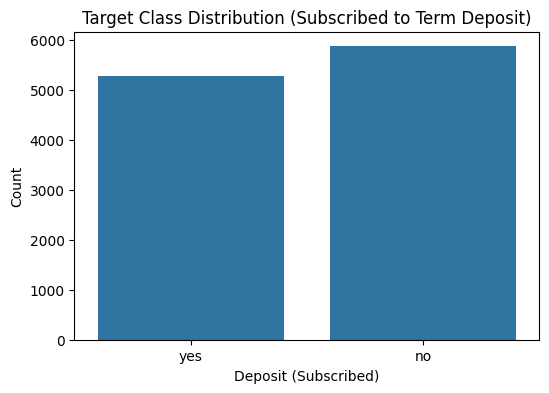

In [ ]:

plt.figure(figsize=(6, 4))
sns.countplot(x='deposit', data=df)
plt.title('Target Class Distribution (Subscribed to Term Deposit)')
plt.xlabel('Deposit (Subscribed)')
plt.ylabel('Count')
plt.show()

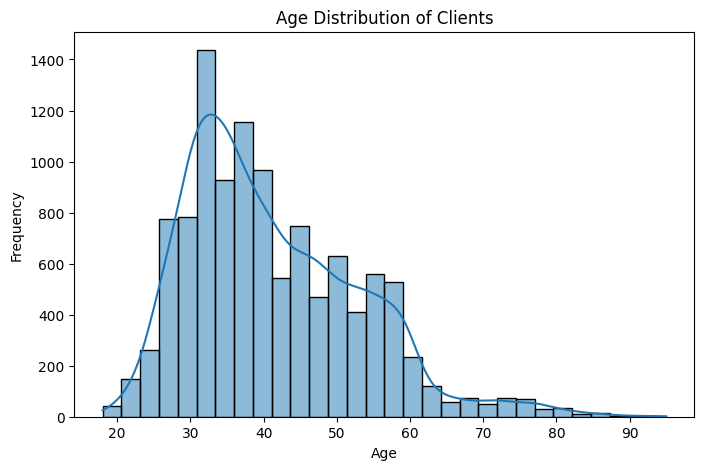

In [ ]:

plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution of Clients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


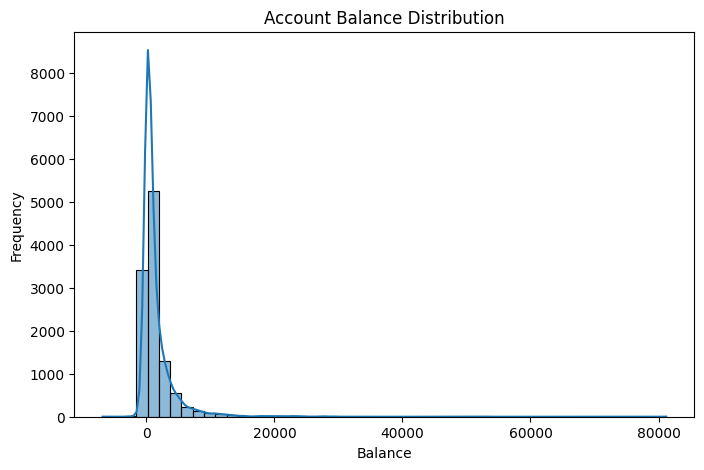

In [ ]:

plt.figure(figsize=(8, 5))
sns.histplot(df['balance'], bins=50, kde=True)
plt.title('Account Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()


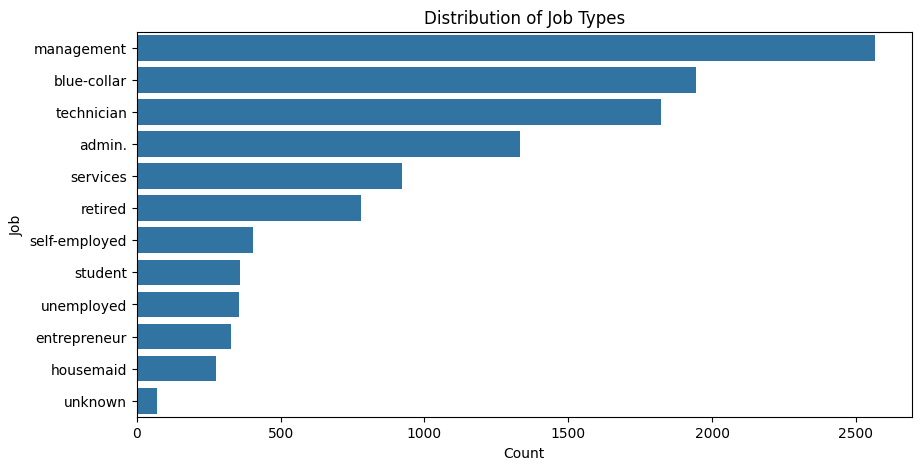

In [ ]:

plt.figure(figsize=(10, 5))
sns.countplot(y='job', data=df, order=df['job'].value_counts().index)
plt.title('Distribution of Job Types')
plt.xlabel('Count')
plt.ylabel('Job')
plt.show()


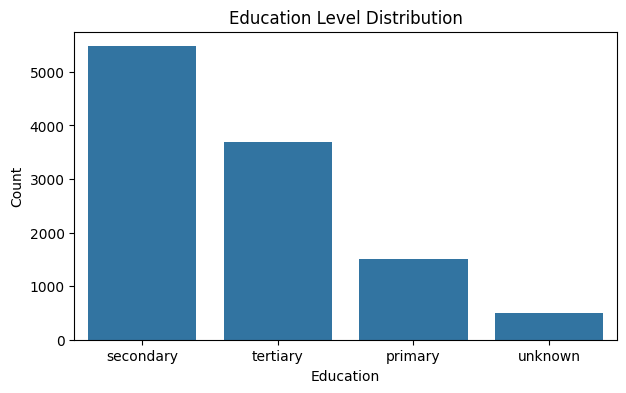

In [ ]:

plt.figure(figsize=(7, 4))
sns.countplot(x='education', data=df, order=df['education'].value_counts().index)
plt.title('Education Level Distribution')
plt.xlabel('Education')
plt.ylabel('Count')
plt.show()


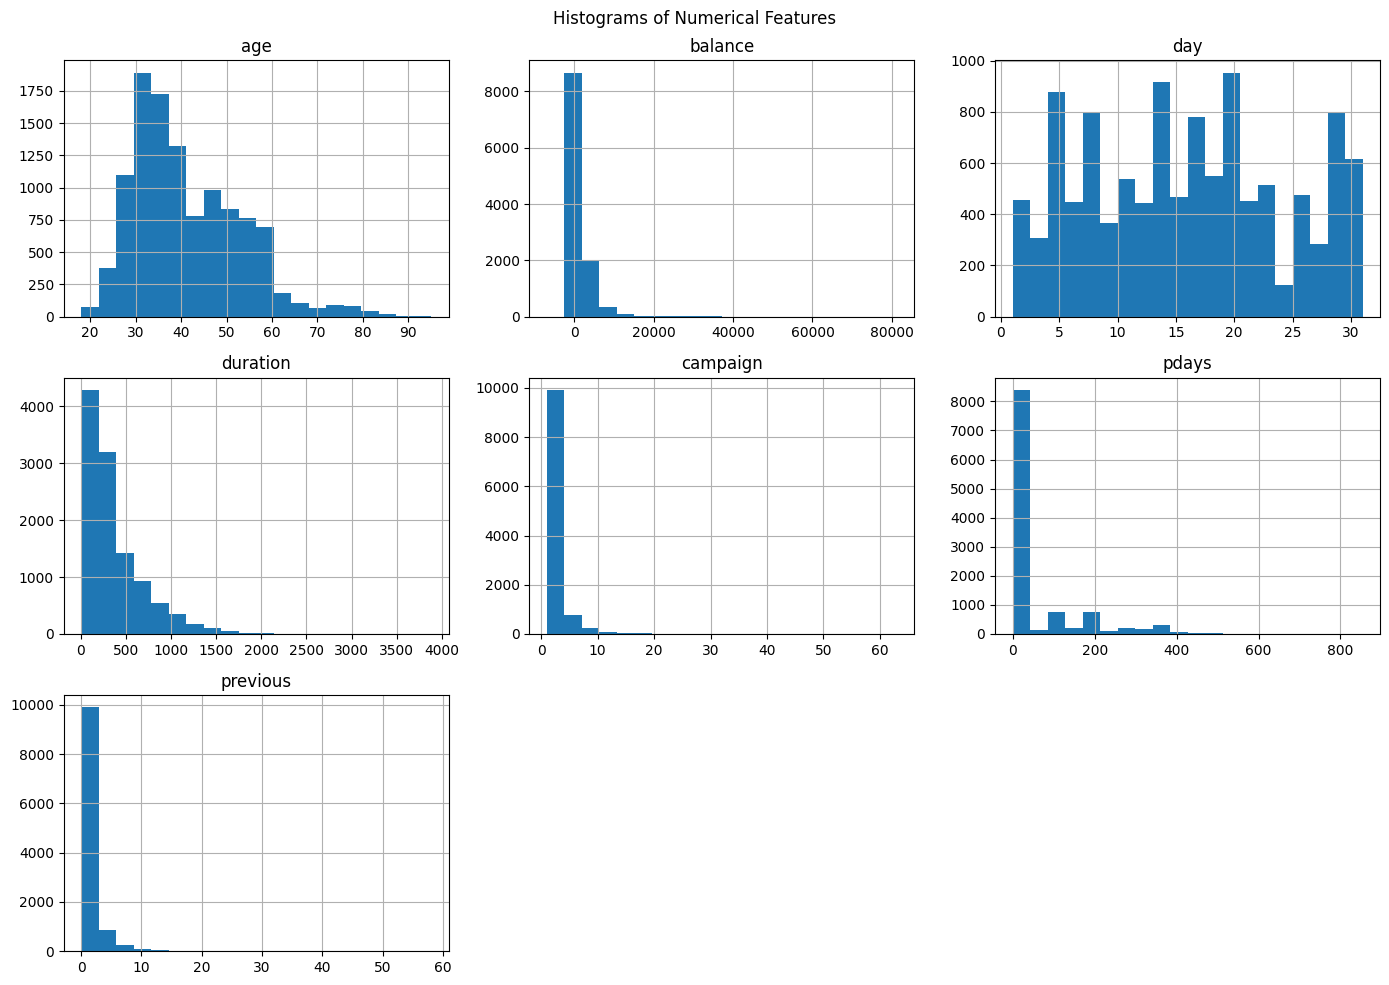

In [ ]:

df[numerical_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout()
plt.show()


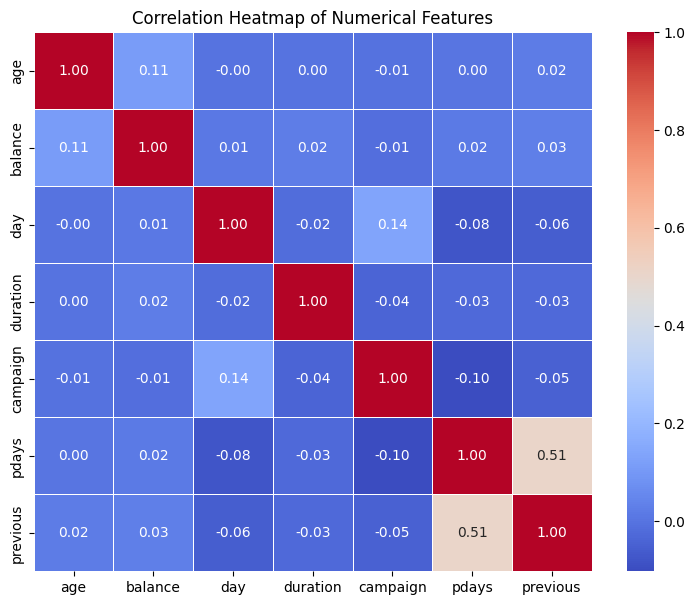

In [ ]:

plt.figure(figsize=(9, 7))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


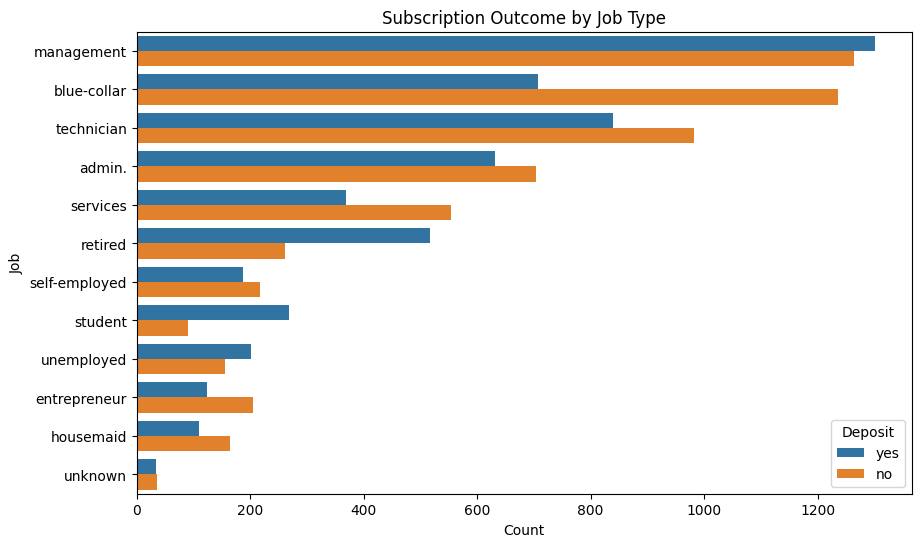

In [ ]:

plt.figure(figsize=(10, 6))
sns.countplot(y='job', hue='deposit', data=df, order=df['job'].value_counts().index)
plt.title('Subscription Outcome by Job Type')
plt.xlabel('Count')
plt.ylabel('Job')
plt.legend(title='Deposit')
plt.show()

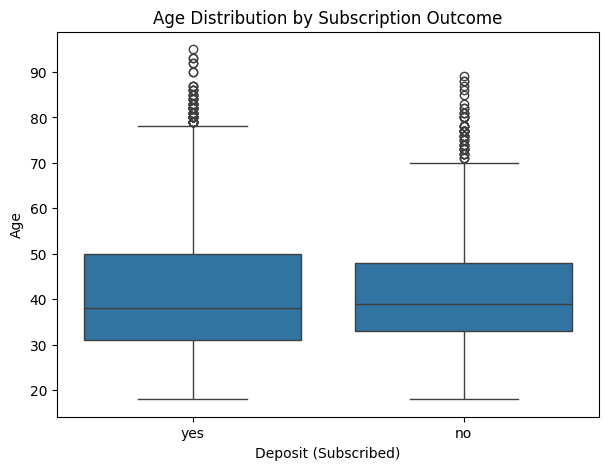

In [ ]:

plt.figure(figsize=(7, 5))
sns.boxplot(x='deposit', y='age', data=df)
plt.title('Age Distribution by Subscription Outcome')
plt.xlabel('Deposit (Subscribed)')
plt.ylabel('Age')
plt.show()

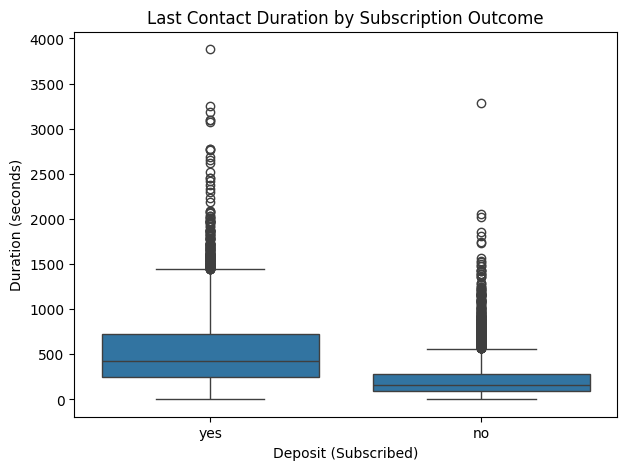

In [ ]:

plt.figure(figsize=(7, 5))
sns.boxplot(x='deposit', y='duration', data=df)
plt.title('Last Contact Duration by Subscription Outcome')
plt.xlabel('Deposit (Subscribed)')
plt.ylabel('Duration (seconds)')
plt.show()

# ***DATA PREPROCESSING***

In [ ]:

data = df.copy()
target_encoder = LabelEncoder()
data['deposit'] = target_encoder.fit_transform(data['deposit'])
print("Target variable encoded:")
print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

Target variable encoded:
{'no': np.int64(0), 'yes': np.int64(1)}


In [ ]:

binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")


Encoded 'default': {'no': np.int64(0), 'yes': np.int64(1)}
Encoded 'housing': {'no': np.int64(0), 'yes': np.int64(1)}
Encoded 'loan': {'no': np.int64(0), 'yes': np.int64(1)}


In [ ]:

nominal_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
data = pd.get_dummies(data, columns=nominal_cols, drop_first=True)
print(f"Dataset shape after one-hot encoding: {data.shape}")
data.head()


Dataset shape after one-hot encoding: (11162, 43)


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,0,2343,1,0,5,1042,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
1,56,0,45,0,0,5,1467,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
2,41,0,1270,1,0,5,1389,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
3,55,0,2476,1,0,5,579,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
4,54,0,184,0,0,5,673,2,-1,0,...,False,False,False,True,False,False,False,False,False,True


In [ ]:
X = data.drop('deposit', axis=1)
y = data['deposit']

print(f"Feature matrix shape (X): {X.shape}")
print(f"Target vector shape (y): {y.shape}")

Feature matrix shape (X): (11162, 42)
Target vector shape (y): (11162,)


In [ ]:
num_features_to_scale = [c for c in numerical_cols if c in X.columns]
scaler = StandardScaler()
X[num_features_to_scale] = scaler.fit_transform(X[num_features_to_scale])
print(f"Scaled numerical features: {num_features_to_scale}")
X.head()


Scaled numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,1.491505,0,0.252525,1,0,-1.265746,1.930226,-0.554168,-0.481184,-0.36326,...,False,False,False,True,False,False,False,False,False,True
1,1.239676,0,-0.459974,0,0,-1.265746,3.154612,-0.554168,-0.481184,-0.36326,...,False,False,False,True,False,False,False,False,False,True
2,-0.019470,0,-0.080160,1,0,-1.265746,2.929901,-0.554168,-0.481184,-0.36326,...,False,False,False,True,False,False,False,False,False,True
3,1.155733,0,0.293762,1,0,-1.265746,0.596366,-0.554168,-0.481184,-0.36326,...,False,False,False,True,False,False,False,False,False,True
4,1.071790,0,-0.416876,0,0,-1.265746,0.867171,-0.186785,-0.481184,-0.36326,...,False,False,False,True,False,False,False,False,False,True


# ***TRAIN - TEST SPLIT***

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"\nTraining target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTesting target distribution:\n{y_test.value_counts(normalize=True)}")


Training set shape: (8929, 42)
Testing set shape: (2233, 42)

Training target distribution:
deposit
0    0.526151
1    0.473849
Name: proportion, dtype: float64

Testing target distribution:
deposit
0    0.526198
1    0.473802
Name: proportion, dtype: float64


# ***MODEL TRAINING***

In [ ]:
models = {}


***Logistic Regression***

In [ ]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train, y_train)
models['Logistic Regression'] = log_reg
print("Logistic Regression model trained.")


Logistic Regression model trained.


***Decision Tree Classifier***

In [ ]:
dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10)
dt_clf.fit(X_train, y_train)
models['Decision Tree'] = dt_clf
print("Decision Tree model trained.")


Decision Tree model trained.


 ***Random Forest Classifier***

In [ ]:
rf_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, max_depth=15)
rf_clf.fit(X_train, y_train)
models['Random Forest'] = rf_clf
print("Random Forest model trained.")


Random Forest model trained.


***K-Nearest Neighbors Classifier***

In [ ]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
models['KNN'] = knn_clf
print("K-Nearest Neighbors model trained.")


K-Nearest Neighbors model trained.


***Support Vector Machine (SVM)***

In [ ]:
svm_clf = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
svm_clf.fit(X_train, y_train)
models['SVM'] = svm_clf
print("SVM model trained.")


SVM model trained.


# ***MODEL EVALUATION***

In [ ]:
results = {}
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    }
    print(f"===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    print("\n")
    return y_pred


===== Logistic Regression =====
Accuracy : 0.8249
Precision: 0.8273
Recall   : 0.7968
F1 Score : 0.8117

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1175
           1       0.83      0.80      0.81      1058

    accuracy                           0.82      2233
   macro avg       0.83      0.82      0.82      2233
weighted avg       0.82      0.82      0.82      2233



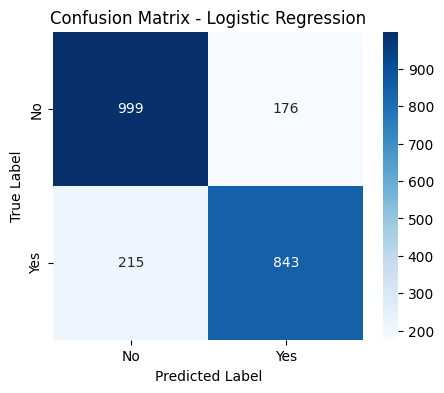

In [ ]:

_ = evaluate_model('Logistic Regression', models['Logistic Regression'], X_test, y_test)


===== Decision Tree =====
Accuracy : 0.8209
Precision: 0.7876
Recall   : 0.8516
F1 Score : 0.8183

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1175
           1       0.79      0.85      0.82      1058

    accuracy                           0.82      2233
   macro avg       0.82      0.82      0.82      2233
weighted avg       0.82      0.82      0.82      2233



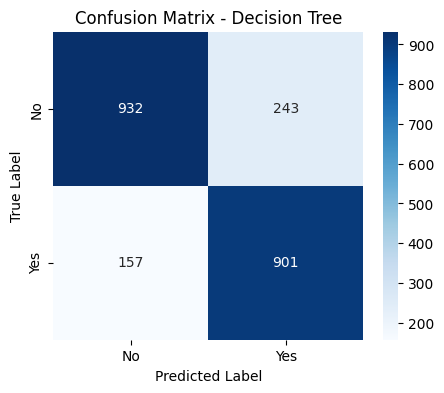

In [ ]:

_ = evaluate_model('Decision Tree', models['Decision Tree'], X_test, y_test)


===== Random Forest =====
Accuracy : 0.8571
Precision: 0.8221
Recall   : 0.8913
F1 Score : 0.8553

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1175
           1       0.82      0.89      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



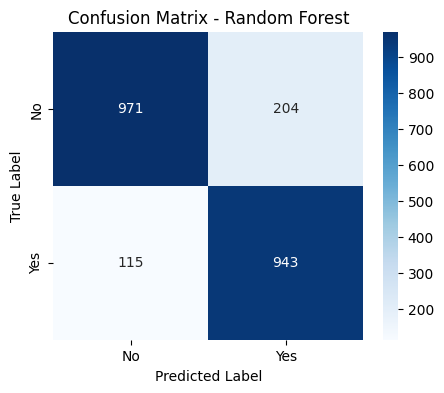

In [ ]:

_ = evaluate_model('Random Forest', models['Random Forest'], X_test, y_test)


===== KNN =====
Accuracy : 0.8312
Precision: 0.8309
Recall   : 0.8081
F1 Score : 0.8194

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1175
           1       0.83      0.81      0.82      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



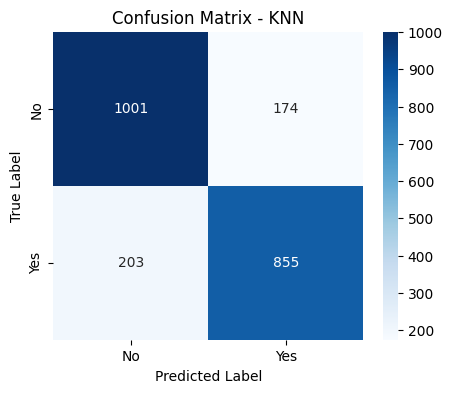

In [ ]:

_ = evaluate_model('KNN', models['KNN'], X_test, y_test)


===== SVM =====
Accuracy : 0.8571
Precision: 0.8261
Recall   : 0.8847
F1 Score : 0.8544

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1175
           1       0.83      0.88      0.85      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



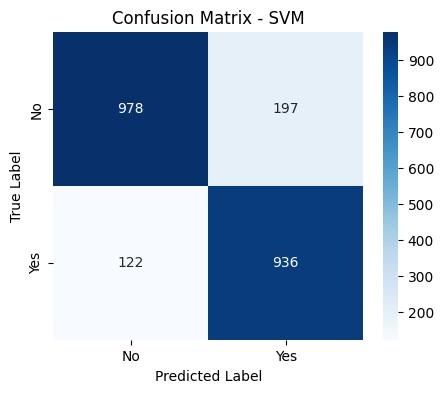

In [ ]:

_ = evaluate_model('SVM', models['SVM'], X_test, y_test)


# ***MODEL COMPARISON TABLE***

In [ ]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)
comparison_df = comparison_df.round(4)
print("Model Comparison Table:\n")
comparison_df


Model Comparison Table:



,Accuracy,Precision,Recall,F1 Score
Random Forest,0.8571,0.8221,0.8913,0.8553
SVM,0.8571,0.8261,0.8847,0.8544
KNN,0.8312,0.8309,0.8081,0.8194
Logistic Regression,0.8249,0.8273,0.7968,0.8117
Decision Tree,0.8209,0.7876,0.8516,0.8183


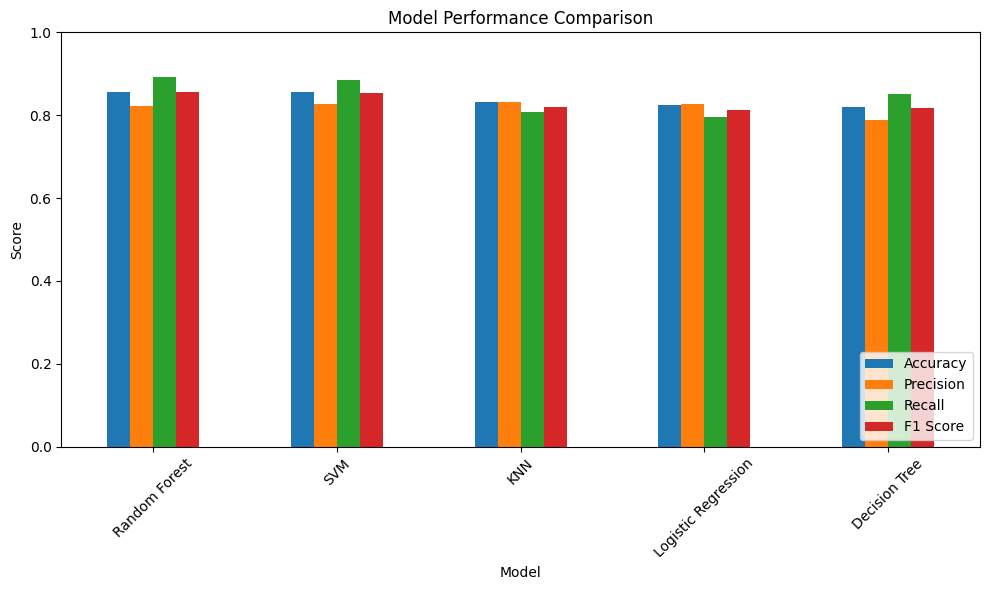

In [ ]:
comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# ***BEST PERFORMING MODEL***

In [ ]:
comparison_df['Combined Score'] = (comparison_df['Accuracy'] + comparison_df['F1 Score']) / 2
best_model_name = comparison_df['Combined Score'].idxmax()
best_model = models[best_model_name]

print(f"Best performing model: {best_model_name}")
print(f"\nMetrics for {best_model_name}:")
print(comparison_df.loc[best_model_name])


Best performing model: Random Forest

Metrics for Random Forest:
Accuracy          0.8571
Precision         0.8221
Recall            0.8913
F1 Score          0.8553
Combined Score    0.8562
Name: Random Forest, dtype: float64


# ***TRANIED MODELS***

In [ ]:

pickle_filenames = {
    'Logistic Regression': 'logistic_regression.pkl',
    'Decision Tree': 'decision_tree.pkl',
    'Random Forest': 'random_forest.pkl',
    'KNN': 'knn.pkl',
    'SVM': 'svm.pkl'
}

for model_name, filename in pickle_filenames.items():
    with open(filename, 'wb') as f:
        pickle.dump(models[model_name], f)
    print(f"Saved {model_name} to '{filename}'")
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('target_encoder.pkl', 'wb') as f:
    pickle.dump(target_encoder, f)
print("\nScaler and target encoder saved as well ('scaler.pkl', 'target_encoder.pkl').")


Saved Logistic Regression to 'logistic_regression.pkl'
Saved Decision Tree to 'decision_tree.pkl'
Saved Random Forest to 'random_forest.pkl'
Saved KNN to 'knn.pkl'
Saved SVM to 'svm.pkl'

Scaler and target encoder saved as well ('scaler.pkl', 'target_encoder.pkl').


In [ ]:
with open(pickle_filenames[best_model_name], 'rb') as f:
    loaded_model = pickle.load(f)

sample_prediction = loaded_model.predict(X_test.iloc[:5])
print(f"Sample predictions from reloaded '{best_model_name}' model: {sample_prediction}")
print(f"Actual labels:                                            {y_test.iloc[:5].values}")


Sample predictions from reloaded 'Random Forest' model: [1 1 1 0 1]
Actual labels:                                            [0 1 0 0 1]
